In [ ]:
import os
import numpy as np
import tifffile as tiff
from skimage.transform import resize

# --- Paths ---
input_root = "/home/tiiairc/GenAI/Datasets/OSCD_output_patches"
output_root = "/home/tiiairc/GenAI/Datasets/OSCD_output_patches_128"

# --- Desired shape ---
target_shape = (128, 128)

# --- Walk through all subdirectories ---
for root, dirs, files in os.walk(input_root):
    for file in files:
        if file.lower().endswith('.tif'):
            input_path = os.path.join(root, file)

            # Create corresponding output path
            relative_path = os.path.relpath(root, input_root)
            output_dir = os.path.join(output_root, relative_path)
            os.makedirs(output_dir, exist_ok=True)

            output_path = os.path.join(output_dir, file)

            # Load and resize the image
            img = tiff.imread(input_path)  # shape: (H, W, C)
            if img.shape[0:2] != (256, 256):
                print(f"Skipping {file} due to unexpected shape: {img.shape}")
                continue

            # Resize (preserve band count)
            resized = np.zeros((target_shape[0], target_shape[1], img.shape[2]), dtype=np.float32)
            for i in range(img.shape[2]):
                resized[:, :, i] = resize(img[:, :, i], target_shape, order=1, preserve_range=True, anti_aliasing=True)

            # Save resized image
            tiff.imwrite(output_path, resized.astype(np.float32))


In [ ]:
import os
import numpy as np
from skimage import io
from scipy.ndimage import zoom
from tqdm import tqdm
import tifffile as tiff

# --- CONFIGURATION ---
DATASET_DIR = "path_to/Onera Satellite Change Detection dataset - Images"  # Replace with actual path
OUTPUT_DIR = "path_to/output_patches_tif_flat"  # Flat output directory
PATCH_SIZE = 256
STRIDE = 256
NORMALISE_IMGS = True


# --- UTILITY FUNCTIONS ---
def adjust_shape(I, s):
    I = I[:s[0], :s[1]]
    si = I.shape
    p0 = max(0, s[0] - si[0])
    p1 = max(0, s[1] - si[1])
    return np.pad(I, ((0, p0), (0, p1)), 'edge')


def read_sentinel_img_band12(path):
    im_name = os.listdir(path)[0][:-7]
    r = io.imread(path + im_name + "B04.tif")
    s = r.shape
    g = io.imread(path + im_name + "B03.tif")
    b = io.imread(path + im_name + "B02.tif")
    nir = io.imread(path + im_name + "B08.tif")

    ir1 = adjust_shape(zoom(io.imread(path + im_name + "B05.tif"), 2), s)
    ir2 = adjust_shape(zoom(io.imread(path + im_name + "B06.tif"), 2), s)
    ir3 = adjust_shape(zoom(io.imread(path + im_name + "B07.tif"), 2), s)
    nir2 = adjust_shape(zoom(io.imread(path + im_name + "B8A.tif"), 2), s)
    swir2 = adjust_shape(zoom(io.imread(path + im_name + "B11.tif"), 2), s)
    swir3 = adjust_shape(zoom(io.imread(path + im_name + "B12.tif"), 2), s)

    uv = adjust_shape(zoom(io.imread(path + im_name + "B01.tif"), 6), s)
    wv = adjust_shape(zoom(io.imread(path + im_name + "B09.tif"), 6), s)

    I = np.stack((uv, b, g, r, ir1, ir2, ir3, nir, nir2, wv, swir2, swir3), axis=2).astype('float')

    if NORMALISE_IMGS:
        I = (I - I.mean()) / I.std()

    return I


def reshape_for_torch(I):
    return I.transpose((2, 0, 1))  # [C, H, W]


def extract_and_save_patches(img, city_name, output_base, patch_size=96, stride=96):
    c, h, w = img.shape
    os.makedirs(output_base, exist_ok=True)
    patch_id = 0

    for i in range(0, h - patch_size + 1, stride):
        for j in range(0, w - patch_size + 1, stride):
            patch = img[:, i:i + patch_size, j:j + patch_size]
            patch_tif = patch.transpose(1, 2, 0)
            out_path = os.path.join(output_base, f"{city_name}_{patch_id:05d}.tif")
            tiff.imwrite(out_path, patch_tif.astype(np.float32))
            patch_id += 1


# --- MAIN PROCESS ---
if __name__ == "__main__":
    city_dirs = [d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))]

    for city in tqdm(city_dirs, desc="Processing cities"):
        img1_path = os.path.join(DATASET_DIR, city, "imgs_1_rect")
        if not os.path.exists(img1_path):
            continue

        try:
            I1 = read_sentinel_img_band12(img1_path)
            I1_torch = reshape_for_torch(I1)
            extract_and_save_patches(I1_torch, city, OUTPUT_DIR, PATCH_SIZE, STRIDE)
        except Exception as e:
            print(f"Failed to process {city}: {e}")


In [ ]:
import os
import numpy as np
import tifffile as tiff
from tqdm import tqdm

# --- CONFIGURATION ---
IMAGE_DIR = "/home/tiiairc/GenAI/Datasets/argyro/"  # Directory containing per-city stacked tif files
OUTPUT_DIR = "/home/tiiairc/GenAI/Datasets/argyro_patches/"  # Flat output directory
PATCH_SIZE = 128
STRIDE = 128
NORMALISE_IMGS = False


# --- UTILITY FUNCTIONS ---
def normalize_image(img):
    mean = img.mean()
    std = img.std()
    return (img - mean) / (std + 1e-8)


def reshape_for_torch(img):
    return img.transpose(2, 0, 1)  # [H, W, C] → [C, H, W]


def extract_and_save_patches(img, base_name, output_base, patch_size=96, stride=96):
    c, h, w = img.shape
    os.makedirs(output_base, exist_ok=True)
    patch_id = 0

    for i in range(0, h - patch_size + 1, stride):
        for j in range(0, w - patch_size + 1, stride):
            patch = img[:, i:i + patch_size, j:j + patch_size]
            patch_tif = patch.transpose(1, 2, 0)  # [C, H, W] → [H, W, C]
            out_path = os.path.join(output_base, f"{base_name}_{patch_id:05d}.tif")
            tiff.imwrite(out_path, patch_tif.astype(np.float32))
            patch_id += 1


if __name__ == "__main__":
    city_dirs = [d for d in os.listdir(IMAGE_DIR) if os.path.isdir(os.path.join(IMAGE_DIR, d))]

    for city in tqdm(city_dirs, desc="Processing cities"):
        city_path = os.path.join(IMAGE_DIR, city)
        tif_files = [f for f in os.listdir(city_path) if f.endswith(".tif")]

        for tif_file in tif_files:
            tif_path = os.path.join(city_path, tif_file)
            base_name = f"{city}_{os.path.splitext(tif_file)[0]}"  # e.g., athens_20240801

            try:
                img = tiff.imread(tif_path)  # [H, W, C]
                if img.ndim != 3:
                    raise ValueError(f"Image must be 3D [H, W, C], got shape: {img.shape}")

                if NORMALISE_IMGS:
                    img = normalize_image(img)

                img = reshape_for_torch(img)  # [C, H, W]
                extract_and_save_patches(img, base_name, OUTPUT_DIR, PATCH_SIZE, STRIDE)
            except Exception as e:
                print(f"❌ Failed to process {tif_path}: {e}")


Processing cities:   0%|          | 0/11 [00:00<?, ?it/s]

Processing cities:  91%|█████████ | 10/11 [01:26<00:08,  8.65s/it]


KeyboardInterrupt: 

In [19]:
import os
import numpy as np
import tifffile as tiff
from tqdm import tqdm
import scipy.ndimage

# --- CONFIGURATION ---
IMAGE_DIR = "/home/tiiairc/GenAI/Datasets/argyro/"  # Directory containing per-city stacked tif files
OUTPUT_DIR = "/home/tiiairc/GenAI/Datasets/argyro_patches/"  # Flat output directory
PATCH_SIZE = 128
STRIDE = 128
NORMALISE_IMGS = True

# --- UTILITY FUNCTIONS ---

def inpaint_nans_with_neighbors(img):
    """
    Replace NaNs in a 3D image [H, W, C] by the average of their valid neighbors (3x3 window).
    Works channel-wise.
    """
    inpainted = np.empty_like(img)

    for c in range(img.shape[2]):
        band = img[:, :, c]
        nan_mask = np.isnan(band)

        if np.any(nan_mask):
            kernel = np.array([[1, 1, 1],
                               [1, 0, 1],
                               [1, 1, 1]], dtype=np.float32)

            filled = np.where(nan_mask, 0, band)
            valid_mask = ~nan_mask

            local_sum = scipy.ndimage.convolve(filled, kernel, mode='constant', cval=0.0)
            local_count = scipy.ndimage.convolve(valid_mask.astype(np.float32), kernel, mode='constant', cval=0.0)

            with np.errstate(invalid='ignore', divide='ignore'):
                band_inpainted = np.where(nan_mask, local_sum / local_count, band)

            inpainted[:, :, c] = band_inpainted
        else:
            inpainted[:, :, c] = band

    return inpainted

def normalize_image(img):
    """
    Normalize each channel using the 2nd and 98th percentiles, ignoring NaNs.
    Output is scaled to [0, 1].
    """
    norm_img = np.empty_like(img, dtype=np.float32)
    for c in range(img.shape[2]):
        band = img[:, :, c]
        band = np.nan_to_num(band, nan=0.0)  # Replace NaNs for percentile calculation
        valid_pixels = band[band > 0]  # Ignore zeros if you expect them to be non-informative
        if valid_pixels.size > 0:
            p2, p98 = np.percentile(valid_pixels, (2, 98))
            norm_band = (band - p2) / (p98 - p2 + 1e-8)
            norm_band = np.clip(norm_band, 0, 1)
        else:
            norm_band = band  # If no valid pixels, leave unchanged
        norm_img[:, :, c] = norm_band
    return norm_img

def reshape_for_torch(img):
    return img.transpose(2, 0, 1)  # [H, W, C] → [C, H, W]

def extract_and_save_patches(img, base_name, output_base, patch_size=128, stride=128):
    c, h, w = img.shape
    os.makedirs(output_base, exist_ok=True)
    patch_id = 0

    for i in range(0, h - patch_size + 1, stride):
        for j in range(0, w - patch_size + 1, stride):
            patch = img[:, i:i + patch_size, j:j + patch_size]
            patch_tif = patch.transpose(1, 2, 0)  # [C, H, W] → [H, W, C]
            out_path = os.path.join(output_base, f"{base_name}_{patch_id:05d}.tif")
            if np.isnan(patch_tif).any():
                continue
            tiff.imwrite(out_path, patch_tif.astype(np.float32))
            patch_id += 1

# --- MAIN SCRIPT ---
if __name__ == "__main__":
    city_dirs = [d for d in os.listdir(IMAGE_DIR) if os.path.isdir(os.path.join(IMAGE_DIR, d))]

    for city in tqdm(city_dirs, desc="Processing cities"):
        city_path = os.path.join(IMAGE_DIR, city)
        tif_files = [f for f in os.listdir(city_path) if f.endswith(".tif")]

        for tif_file in tif_files:
            tif_path = os.path.join(city_path, tif_file)
            base_name = f"{city}_{os.path.splitext(tif_file)[0]}"

            try:
                img = tiff.imread(tif_path)  # [H, W, C]
                if img.ndim != 3:
                    raise ValueError(f"Image must be 3D [H, W, C], got shape: {img.shape}")

                # Replace NaNs with local averages
                if np.isnan(img).any():
                    img = inpaint_nans_with_neighbors(img)

                if NORMALISE_IMGS:
                    img = normalize_image(img)

                img = reshape_for_torch(img)  # [C, H, W]
                extract_and_save_patches(img, base_name, OUTPUT_DIR, PATCH_SIZE, STRIDE)

            except Exception as e:
                print(f"❌ Failed to process {tif_path}: {e}")


Processing cities:   0%|          | 0/11 [00:00<?, ?it/s]

Processing cities: 100%|██████████| 11/11 [04:51<00:00, 26.54s/it]


In [ ]:
# import os
# import random

# def delete_random_files(directory, percentage=25):
#     if not os.path.isdir(directory):
#         print(f"The path '{directory}' is not a valid directory.")
#         return

#     files = [f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))]

#     if not files:
#         print("No files found in the directory.")
#         return

#     num_to_delete = int(len(files) * (percentage / 100))
#     files_to_delete = random.sample(files, num_to_delete)

#     print(f"Deleting {num_to_delete} out of {len(files)} files...")

#     for file_name in files_to_delete:
#         file_path = os.path.join(directory, file_name)
#         os.remove(file_path)
#         # print(f"Deleted: {file_path}")
#         # break

#     print("Deletion complete.")

# # Example usage:
# delete_random_files("/home/tiiairc/GenAI/Datasets/argyro_patches")


Deleting 6985 out of 27941 files...
Deletion complete.


Loaded image shape: (128, 128, 12)
Number of NaNs: 0
Max (ignoring NaNs): 3.7249315
Min (ignoring NaNs): -1.7140326


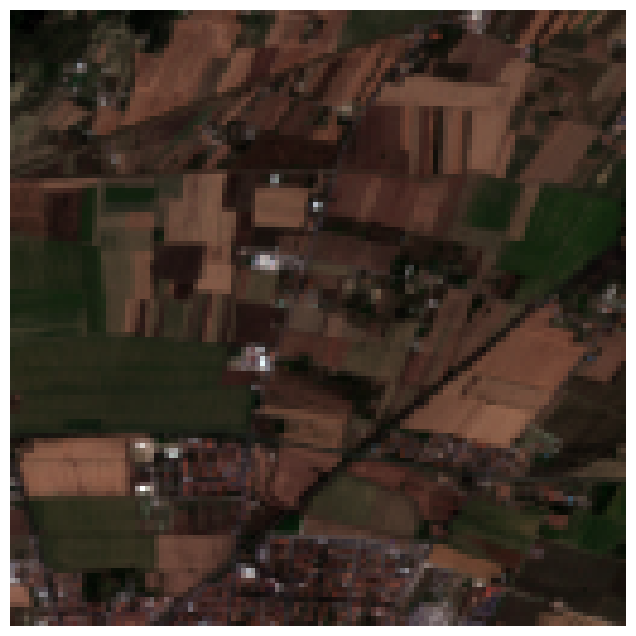

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.transform import resize

# Path to your 12-band Sentinel image
tif_path = "/home/tiiairc/GenAI/Datasets/OSCD_output_patches_128/pisa/00001.tif"

# Load image
img = io.imread(tif_path)  # (H, W, C)
print("Loaded image shape:", img.shape)

# Report basic stats
nan_count = np.isnan(img).sum()
print("Number of NaNs:", nan_count)
print("Max (ignoring NaNs):", np.nanmax(img))
print("Min (ignoring NaNs):", np.nanmin(img))

# Select RGB bands (assumed order: B=1, G=2, R=3)
blue = img[:, :, 1]
green = img[:, :, 2]
red = img[:, :, 3]

red1 = (red - red.min()) / (red.max() - red.min())
green1 = (green - green.min()) / (green.max() - green.min())
blue1 = (blue - blue.min()) / (blue.max() - blue.min())
# Better normalization using robust percentiles
def normalize(band):
    band = np.nan_to_num(band, nan=0)  # Replace NaNs with 0
    p2, p98 = np.percentile(band[band > 0], (1, 99))
    return np.clip((band - p2) / (p98 - p2), 0, 1)

# Stack normalized RGB
rgb = np.stack([
    (red1),
    (green1),
    (blue1)
], axis=-1)

# Show the RGB image
plt.figure(figsize=(8, 8))
# plt.imshow(resize(rgb, (64, 64), preserve_range=True, anti_aliasing=True))
plt.imshow(rgb)

# plt.title("RGB Composite (Normalized)")
plt.axis('off')
plt.show()


img_size (128, 128) patch_size (8, 8) frames 12 t_patch_size 3
model initialized
torch.Size([1, 4096, 192])
LOWRES torch.Size([1, 12, 128, 128])
pred torch.Size([1, 4096, 192])
target torch.Size([1, 4096, 192])
torch.Size([1, 4096, 192]) torch.Size([12, 256, 256])


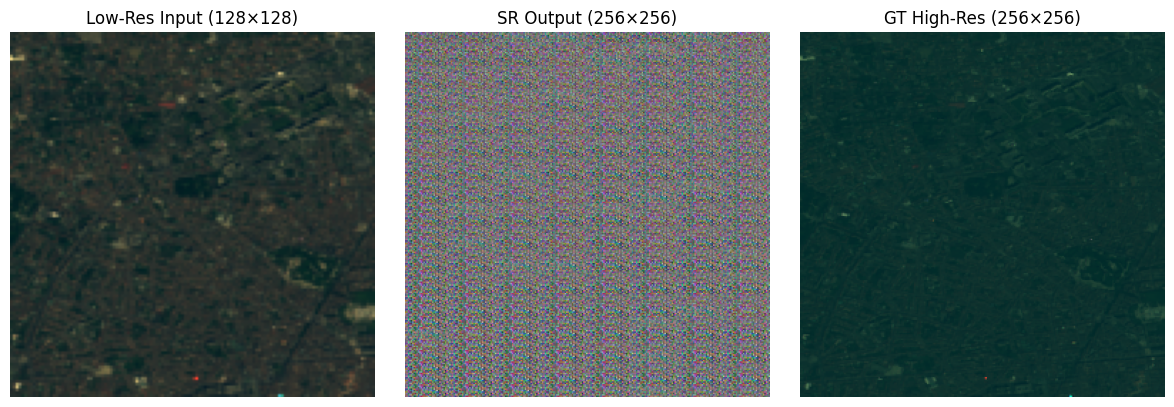

Loss: 0.0388


In [36]:
import torch
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image
from skimage import io
import os
import numpy as np
from superres_models_mae_spectral import MaskedAutoencoderViT  

# ---- SETUP ----
lowres_path = "/home/tiiairc/GenAI/Datasets/OSCD_output_patches_128/bordeaux/00000.tif"
highres_path = "/home/tiiairc/GenAI/Datasets/OSCD_output_patches/bordeaux/00000.tif"
checkpoint_path = "/home/tiiairc/GenAI/SpectralGPT/chrysatest/checkpoint-199.pth"

mean = [1370.19151926, 1184.3824625, 1120.77120066, 1136.26026392,
        1263.73947144, 1645.40315151, 1846.87040806, 1762.59530783,
        1972.62420416, 582.72633433, 14.77112979, 1732.16362238, 1247.91870117]
std = [633.15169573, 650.2842772, 712.12507725, 965.23119807,
       948.9819932, 1108.06650639, 1258.36394548, 1233.1492281,
       1364.38688993, 472.37967789, 14.3114637, 1310.36996126, 1087.6020813]

# -------------------- Load low-res --------------------
lowr = io.imread(lowres_path).transpose(2, 0, 1)  # [C, H, W]
lowr = torch.tensor(lowr).float()
lowr = (lowr - lowr.min(dim=1, keepdim=True)[0].min(dim=2, keepdim=True)[0]) / \
       (lowr.max(dim=1, keepdim=True)[0].max(dim=2, keepdim=True)[0] + 1e-6)
lowr = lowr.unsqueeze(0).cuda()  # [1, C, 128, 128]

# -------------------- Load high-res --------------------
highr = io.imread(highres_path).transpose(2, 0, 1)  # [C, H, W]
highr = torch.tensor(highr).float()
highr = (highr - highr.min(dim=1, keepdim=True)[0].min(dim=2, keepdim=True)[0]) / \
        (highr.max(dim=1, keepdim=True)[0].max(dim=2, keepdim=True)[0] + 1e-6)
highr = highr.unsqueeze(0).cuda()  # [1, C, 256, 256]


model = MaskedAutoencoderViT(
    img_size=128,
    in_chans=1,
    patch_size=8,
    embed_dim=768,
    depth=12,
    num_heads=12,
    mlp_ratio=4,
    num_frames=12,
    pred_t_dim=12,
    t_patch_size=3,
    mask_ratio=0.5
    
)

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model'], strict=False)
model.eval().cuda()


# -------------------- Run inference --------------------
with torch.no_grad():
    loss, pred, mask = model(lowr, highr)
    reconall = model.unpatchify(pred).squeeze(0).cpu()  # [C, 256, 256]
    recon = reconall[0]
# -------------------- Reverse Normalize --------------------
def reverse_sentinel_normalize(x, mean, std):
    mean = torch.tensor(mean).view(-1, 1, 1)
    std = torch.tensor(std).view(-1, 1, 1)
    return x * (4 * std) + (mean - 2 * std)

# ---- RGB bands [3,2,1] = R,G,B
rgb_idx = [3, 2, 1]
rgb_mean = [mean[i] for i in rgb_idx]
rgb_std = [std[i] for i in rgb_idx]

# Low-res
low_rgb = reverse_sentinel_normalize(lowr[0, rgb_idx].cpu(), rgb_mean, rgb_std)
low_rgb = (low_rgb - low_rgb.min()) / (low_rgb.max() - low_rgb.min())

# High-res GT
gt_rgb = reverse_sentinel_normalize(highr[0, rgb_idx].cpu(), rgb_mean, rgb_std)
gt_rgb = (gt_rgb - gt_rgb.min()) / (gt_rgb.max() - gt_rgb.min())


print(pred.shape, recon.shape)
# Reconstructed SR
sr_rgb = recon[rgb_idx]# reverse_sentinel_normalize(recon[rgb_idx], rgb_mean, rgb_std)
sr_rgb = (sr_rgb - sr_rgb.min()) / (sr_rgb.max() - sr_rgb.min())

# -------------------- Plot results --------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(to_pil_image(low_rgb))
plt.title("Low-Res Input (128×128)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(to_pil_image(sr_rgb))
plt.title("SR Output (256×256)")
plt.axis('off')

plt.subplot(1, 3, 3)
recon[rgb_idx]
# plt.imshow(to_pil_image(recon[rgb_idx]))
plt.imshow(to_pil_image(gt_rgb))
plt.title("GT High-Res (256×256)")
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Loss: {loss.item():.4f}")


In [82]:
!python superres_main_pretrain.py \
--batch_size 4 --accum_iter 16 --blr 0.0002 \
--epochs 200 --warmup_epochs 20 --num_workers 16 \
--input_size 128 --patch_size 8 \
--mask_ratio 0.0 --model_type tensor \
--model mae_vit_base_patch8_128 --dataset_type superres  --train_path /kaggle/working/eurosat_test.csv \
--output_dir chrysatest   --log_dir chrysatest \
--resume  /home/tiiairc/GenAI/SpectralGPT/chrysatest/checkpoint-105.pth #/home/tiiairc/GenAI/Checkpoints/SpectralGPT+.pth

Traceback (most recent call last):
  File "/home/tiiairc/GenAI/SpectralGPT/superres_main_pretrain.py", line 20, in <module>
    import timm
  File "/home/tiiairc/miniconda3/envs/spectralgpt/lib/python3.10/site-packages/timm/__init__.py", line 2, in <module>
    from .models import create_model, list_models, is_model, list_modules, model_entrypoint, \
  File "/home/tiiairc/miniconda3/envs/spectralgpt/lib/python3.10/site-packages/timm/models/__init__.py", line 1, in <module>
    from .byoanet import *
  File "/home/tiiairc/miniconda3/envs/spectralgpt/lib/python3.10/site-packages/timm/models/byoanet.py", line 15, in <module>
    from timm.data import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD
  File "/home/tiiairc/miniconda3/envs/spectralgpt/lib/python3.10/site-packages/timm/data/__init__.py", line 7, in <module>
    from .loader import create_loader
  File "/home/tiiairc/miniconda3/envs/spectralgpt/lib/python3.10/site-packages/timm/data/loader.py", line 12, in <module>
    from .transfo

In [ ]:
!python main_pretrain.py \
--batch_size 4 --accum_iter 16 --blr 0.0002 \
--epochs 400 --warmup_epochs 20 --num_workers 16 \
--input_size 128 --patch_size 4 \
--mask_ratio 0.1 --model_type tensor \
--model mae_vit_base_patch8_128 --dataset_type superres  \
--output_dir chrysatest_4   --log_dir chrysatest_4 \
--resume /home/tiiairc/GenAI/Checkpoints/SpectralGPT+.pth

Not using distributed mode
[19:54:54.009970] job dir: /home/tiiairc/GenAI/SpectralGPT
[19:54:54.010037] Namespace(batch_size=4,
epochs=400,
accum_iter=16,
model_type='tensor',
model='mae_vit_base_patch8_128',
input_size=128,
patch_size=8,
mask_ratio=0.1,
spatial_mask=False,
norm_pix_loss=False,
weight_decay=0.05,
lr=None,
blr=0.0002,
min_lr=0.0,
warmup_epochs=20,
train_path='/kaggle/working/eurosat_test.csv',
dataset_type='superres',
masked_bands=None,
dropped_bands=None,
grouped_bands=[],
output_dir='chrysatest_3',
log_dir='chrysatest_3',
device='cuda',
seed=0,
resume='/home/tiiairc/GenAI/Checkpoints/SpectralGPT+.pth',
resume_different_size='',
wandb=None,
start_epoch=0,
num_workers=16,
pin_mem=True,
world_size=8,
local_rank=0,
dist_on_itp=False,
dist_url='env://',
distributed=False)
[19:54:54.341260] torch.Size([12, 128, 128]) torch.Size([12, 128, 128])
[19:54:54.341302] <util.datasets.SentinelSuperResolutionDataset object at 0x76efcf113a00>
[19:54:54.341321] <util.datasets.SentinelS

In [2]:
import torch
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image
from skimage import io
import os
import numpy as np
from models_mae_spectral import MaskedAutoencoderViT  

# ---- SETUP ----
lowres_path = "/home/tiiairc/GenAI/Datasets/OSCD_output_patches_128/bordeaux/00000.tif"
checkpoint_path = "/home/tiiairc/GenAI/SpectralGPT/chrysatest_2/checkpoint-270.pth"
highres_path = "/home/tiiairc/GenAI/Datasets/OSCD_output_patches_128/bordeaux/00000.tif"

mean = [1370.19151926, 1184.3824625, 1120.77120066, 1136.26026392,
        1263.73947144, 1645.40315151, 1846.87040806, 1762.59530783,
        1972.62420416, 582.72633433, 14.77112979, 1732.16362238, 1247.91870117]
std = [633.15169573, 650.2842772, 712.12507725, 965.23119807,
       948.9819932, 1108.06650639, 1258.36394548, 1233.1492281,
       1364.38688993, 472.37967789, 14.3114637, 1310.36996126, 1087.6020813]

# -------------------- Load low-res --------------------
lowr = io.imread(lowres_path).transpose(2, 0, 1)  # [C, H, W]
lowr = torch.tensor(lowr).float()
lowr = (lowr - lowr.min(dim=1, keepdim=True)[0].min(dim=2, keepdim=True)[0]) / \
       (lowr.max(dim=1, keepdim=True)[0].max(dim=2, keepdim=True)[0] + 1e-6)
lowr = lowr.unsqueeze(0).cuda()  # [1, C, 128, 128]

# -------------------- Load high-res --------------------
highr = io.imread(highres_path).transpose(2, 0, 1)  # [C, H, W]
highr = torch.tensor(highr).float()
highr = (highr - highr.min(dim=1, keepdim=True)[0].min(dim=2, keepdim=True)[0]) / \
        (highr.max(dim=1, keepdim=True)[0].max(dim=2, keepdim=True)[0] + 1e-6)
highr = highr.unsqueeze(0).cuda()  # [1, C, 256, 256]


model = MaskedAutoencoderViT(
    img_size=128,
    in_chans=1,
    patch_size=8,
    embed_dim=768,
    depth=12,
    num_heads=12,
    mlp_ratio=4,
    num_frames=12,
    pred_t_dim=12,
    t_patch_size=3,
    mask_ratio=0.05
    
)

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model'], strict=False)
model.eval().cuda()


# -------------------- Run inference --------------------
with torch.no_grad():
    loss, pred, mask = model(lowr)
    reconall = model.unpatchify(pred).squeeze(0).cpu()  # [C, 256, 256]
    recon = reconall[0]
# -------------------- Reverse Normalize --------------------
def reverse_sentinel_normalize(x, mean, std):
    mean = torch.tensor(mean).view(-1, 1, 1)
    std = torch.tensor(std).view(-1, 1, 1)
    return x * (4 * std) + (mean - 2 * std)

# ---- RGB bands [3,2,1] = R,G,B
rgb_idx = [3, 2, 1]
rgb_mean = [mean[i] for i in rgb_idx]
rgb_std = [std[i] for i in rgb_idx]

# Low-res
low_rgb = reverse_sentinel_normalize(lowr[0, rgb_idx].cpu(), rgb_mean, rgb_std)
low_rgb = (low_rgb - low_rgb.min()) / (low_rgb.max() - low_rgb.min())


print(pred.shape, recon.shape)
# Reconstructed SR
sr_rgb = recon[rgb_idx]*255# reverse_sentinel_normalize(recon[rgb_idx], rgb_mean, rgb_std)
sr_rgb = (sr_rgb - sr_rgb.min()) / (sr_rgb.max() - sr_rgb.min())

# -------------------- Plot results --------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(to_pil_image(low_rgb))
plt.title("Low-Res Input (128×128) Groundtruth")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(to_pil_image(sr_rgb))
plt.title("SR Output  (128×128) ")
plt.axis('off')



plt.tight_layout()
plt.show()

print(f"Loss: {loss.item():.4f}")


img_size (128, 128) patch_size (8, 8) frames 12 t_patch_size 3
model initialized


FileNotFoundError: [Errno 2] No such file or directory: '/home/tiiairc/GenAI/SpectralGPT/chrysatest_2/checkpoint-270.pth'

img_size (128, 128) patch_size (8, 8) frames 12 t_patch_size 3
model initialized
xx!!before prediction torch.Size([1, 1024, 512])
xx!!after prediction torch.Size([1, 1024, 192])
torch.Size([1, 1024, 192])
torch.Size([1, 1, 12, 128, 128])
torch.Size([1, 1024, 192]) torch.Size([12, 128, 128])


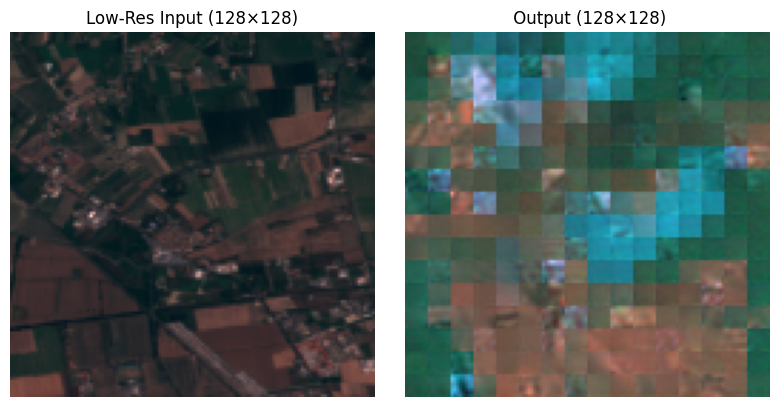

Loss: 1.3788


In [5]:
import torch
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image
from skimage import io
import os
import numpy as np
from models_mae_spectral import MaskedAutoencoderViT  

# ---- SETUP ----
lowres_path = "/home/tiiairc/GenAI/Datasets/OSCD_output_patches_128/pisa/00000.tif"
checkpoint_path = "/home/tiiairc/GenAI/SpectralGPT/chrysatest_2/checkpoint-420.pth"

mean = [1370.19151926, 1184.3824625, 1120.77120066, 1136.26026392,
        1263.73947144, 1645.40315151, 1846.87040806, 1762.59530783,
        1972.62420416, 582.72633433, 14.77112979, 1732.16362238, 1247.91870117]
std = [633.15169573, 650.2842772, 712.12507725, 965.23119807,
       948.9819932, 1108.06650639, 1258.36394548, 1233.1492281,
       1364.38688993, 472.37967789, 14.3114637, 1310.36996126, 1087.6020813]

# -------------------- Load low-res --------------------
lowr = io.imread(lowres_path).transpose(2, 0, 1)  # [C, H, W]
lowr = torch.tensor(lowr).float()
lowr = (lowr - lowr.min(dim=1, keepdim=True)[0].min(dim=2, keepdim=True)[0]) / \
       (lowr.max(dim=1, keepdim=True)[0].max(dim=2, keepdim=True)[0] + 1e-6)
lowr = lowr.unsqueeze(0).cuda()  # [1, C, 128, 128]

# -------------------- Load high-res --------------------
highr = io.imread(highres_path).transpose(2, 0, 1)  # [C, H, W]
highr = torch.tensor(highr).float()
highr = (highr - highr.min(dim=1, keepdim=True)[0].min(dim=2, keepdim=True)[0]) / \
        (highr.max(dim=1, keepdim=True)[0].max(dim=2, keepdim=True)[0] + 1e-6)
highr = highr.unsqueeze(0).cuda()  # [1, C, 256, 256]


model = MaskedAutoencoderViT(
    img_size=128,
    in_chans=1,
    patch_size=8,
    embed_dim=768,
    depth=12,
    num_heads=12,
    mlp_ratio=4,
    num_frames=12,
    pred_t_dim=12,
    t_patch_size=3,
    mask_ratio=0.05
    
)

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model'], strict=False)
model.eval().cuda()


# -------------------- Run inference --------------------
with torch.no_grad():
    loss, pred, mask = model(lowr)
    reconall = model.unpatchify(pred).squeeze(0).cpu()  # [C, 256, 256]
    recon = reconall[0]
# -------------------- Reverse Normalize --------------------
def reverse_sentinel_normalize(x, mean, std):
    mean = torch.tensor(mean).view(-1, 1, 1)
    std = torch.tensor(std).view(-1, 1, 1)
    return x * (4 * std) + (mean - 2 * std)

# ---- RGB bands [3,2,1] = R,G,B
rgb_idx = [3, 2, 1]
rgb_mean = [mean[i] for i in rgb_idx]
rgb_std = [std[i] for i in rgb_idx]

# Low-res
low_rgb = reverse_sentinel_normalize(lowr[0, rgb_idx].cpu(), rgb_mean, rgb_std)
low_rgb = (low_rgb - low_rgb.min()) / (low_rgb.max() - low_rgb.min())


print(pred.shape, recon.shape)
# Reconstructed SR
sr_rgb = recon[rgb_idx]*255# reverse_sentinel_normalize(recon[rgb_idx], rgb_mean, rgb_std)
sr_rgb = (sr_rgb - sr_rgb.min()) / (sr_rgb.max() - sr_rgb.min())

# -------------------- Plot results --------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(to_pil_image(low_rgb))
plt.title("Low-Res Input (128×128)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(to_pil_image(sr_rgb))
plt.title(" Output (128×128)")
plt.axis('off')



plt.tight_layout()
plt.show()

print(f"Loss: {loss.item():.4f}")


img_size (128, 128) patch_size (8, 8) frames 12 t_patch_size 3


model initialized
torch.Size([1, 1024, 192]) torch.Size([12, 128, 128])


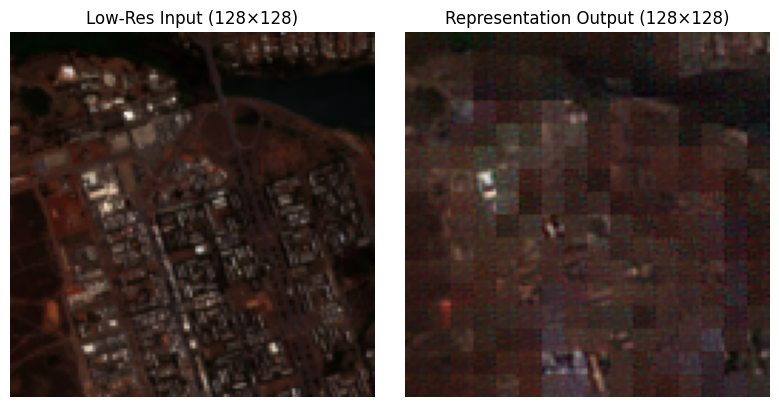

Loss: 0.2146


In [5]:
import torch
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image
from skimage import io
import os
import numpy as np
from models_mae_spectral import MaskedAutoencoderViT  

# ---- SETUP ----
lowres_path = "/home/tiiairc/GenAI/Datasets/OSCD_output_patches_128/brasilia/00000.tif"
checkpoint_path = "/home/tiiairc/GenAI/SpectralGPT/chrysatest_3/checkpoint-35.pth"

mean = [1370.19151926, 1184.3824625, 1120.77120066, 1136.26026392,
        1263.73947144, 1645.40315151, 1846.87040806, 1762.59530783,
        1972.62420416, 582.72633433, 14.77112979, 1732.16362238, 1247.91870117]
std = [633.15169573, 650.2842772, 712.12507725, 965.23119807,
       948.9819932, 1108.06650639, 1258.36394548, 1233.1492281,
       1364.38688993, 472.37967789, 14.3114637, 1310.36996126, 1087.6020813]

# -------------------- Load low-res --------------------
lowr = io.imread(lowres_path).transpose(2, 0, 1)  # [C, H, W]
lowr = torch.tensor(lowr).float()
lowr = (lowr - lowr.min(dim=1, keepdim=True)[0].min(dim=2, keepdim=True)[0]) / \
       (lowr.max(dim=1, keepdim=True)[0].max(dim=2, keepdim=True)[0] + 1e-6)
lowr = lowr.unsqueeze(0).cuda()  # [1, C, 128, 128]

# -------------------- Load high-res --------------------
# highr = io.imread(highres_path).transpose(2, 0, 1)  # [C, H, W]
# highr = torch.tensor(highr).float()
# highr = (highr - highr.min(dim=1, keepdim=True)[0].min(dim=2, keepdim=True)[0]) / \
#         (highr.max(dim=1, keepdim=True)[0].max(dim=2, keepdim=True)[0] + 1e-6)
# highr = highr.unsqueeze(0).cuda()  # [1, C, 256, 256]


model = MaskedAutoencoderViT(
    img_size=128,
    in_chans=1,
    patch_size=8,
    embed_dim=768,
    depth=12,
    num_heads=12,
    mlp_ratio=4,
    num_frames=12,
    pred_t_dim=12,
    t_patch_size=3,
    mask_ratio=0.05
    
)

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model'], strict=False)
model.eval().cuda()


# -------------------- Run inference --------------------
with torch.no_grad():
    loss, pred, mask = model(lowr)
    reconall = model.unpatchify(pred).squeeze(0).cpu()  # [C, 256, 256]
    recon = reconall[0]
# -------------------- Reverse Normalize --------------------
def reverse_sentinel_normalize(x, mean, std):
    mean = torch.tensor(mean).view(-1, 1, 1)
    std = torch.tensor(std).view(-1, 1, 1)
    return x * (4 * std) + (mean - 2 * std)

# ---- RGB bands [3,2,1] = R,G,B
rgb_idx = [3, 2, 1]
rgb_mean = [mean[i] for i in rgb_idx]
rgb_std = [std[i] for i in rgb_idx]

# Low-res
low_rgb = lowr[0, rgb_idx].cpu() #reverse_sentinel_normalize(lowr[0, rgb_idx].cpu(), rgb_mean, rgb_std)
low_rgb = (low_rgb - low_rgb.min()) / (low_rgb.max() - low_rgb.min())


print(pred.shape, recon.shape)
# Reconstructed SR
sr_rgb = recon[rgb_idx]# reverse_sentinel_normalize(recon[rgb_idx], rgb_mean, rgb_std)
sr_rgb = (sr_rgb - sr_rgb.min()) / (sr_rgb.max() - sr_rgb.min())

# -------------------- Plot results --------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(to_pil_image(low_rgb))
plt.title("Low-Res Input (128×128)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(to_pil_image(sr_rgb))
plt.title("Representation Output (128×128)")
plt.axis('off')



plt.tight_layout()
plt.show()

print(f"Loss: {loss.item():.4f}")


In [14]:
import torch
import numpy as np
import random

SEED = 42  # or any integer of your choice

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # if using multi-GPU

np.random.seed(SEED)
random.seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


img_size (128, 128) patch_size (8, 8) frames 12 t_patch_size 3
model initialized






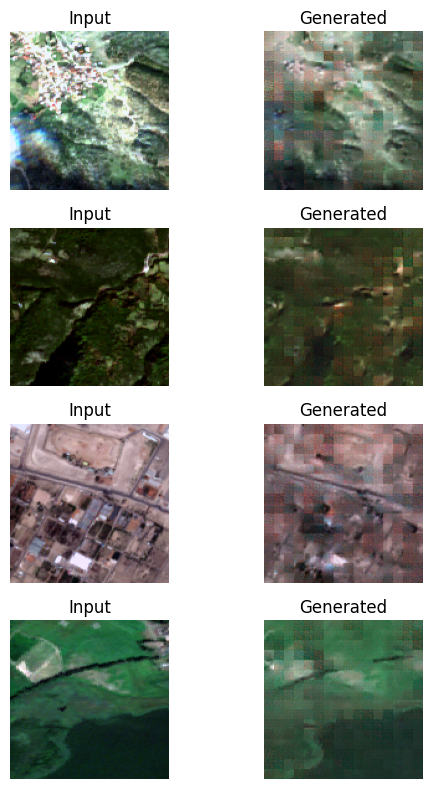

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
import torch
from torchvision.transforms.functional import to_pil_image
from models_mae_spectral import MaskedAutoencoderViT

# ----- CONFIG -----
PATCH_DIR = "/home/tiiairc/GenAI/Datasets/argyro_patches"
CHECKPOINT_PATH = '/home/tiiairc/GenAI/Checkpoints/SpectralGPT+.pth'#"/home/tiiairc/GenAI/SpectralGPT/deepdecoder_no_checkpoint/checkpoint-45.pth"
CHECKPOINT_PATH = "/home/tiiairc/GenAI/SpectralGPT/deepdecoder_no_checkpoint/checkpoint-75.pth"
NUM_SAMPLES = 4

mean = [1370.19151926, 1184.3824625, 1120.77120066, 1136.26026392,
        1263.73947144, 1645.40315151, 1846.87040806, 1762.59530783,
        1972.62420416, 582.72633433, 14.77112979, 1732.16362238, 1247.91870117]
std = [633.15169573, 650.2842772, 712.12507725, 965.23119807,
       948.9819932, 1108.06650639, 1258.36394548, 1233.1492281,
       1364.38688993, 472.37967789, 14.3114637, 1310.36996126, 1087.6020813]
rgb_idx = [3, 2, 1]  # R, G, B

# ----- MODEL -----
model = MaskedAutoencoderViT(
    img_size=128,
    in_chans=1,
    patch_size=8,
    embed_dim=768,
    depth=12,
    num_heads=12,
    mlp_ratio=4,
    num_frames=12,
    pred_t_dim=12,
    t_patch_size=3,
    mask_ratio=0.05
)
checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only= False)
model.load_state_dict(checkpoint['model'], strict=False)
model.eval().cuda()

# ----- Sample 20 random .tif images -----
all_files = [os.path.join(dp, f) for dp, _, fn in os.walk(PATCH_DIR) for f in fn if f.endswith('.tif')]
selected_files = random.sample(all_files, NUM_SAMPLES)
# ----- Inference and visualization -----
fig, axs = plt.subplots(NUM_SAMPLES, 2, figsize=(6, NUM_SAMPLES * 2))

shown = 0  # Counter for successful images

for file_path in selected_files:

    img = io.imread(file_path)
    if img.ndim != 3 or img.shape[2] < 4:
        raise ValueError(f"Image has insufficient channels: {img.shape}")

    img = img.transpose(2, 0, 1)  # [C, H, W]
    img_tensor = torch.tensor(img).float()

    # Normalize per-image
    img_tensor = (img_tensor - img_tensor.min(dim=1, keepdim=True)[0].min(dim=2, keepdim=True)[0]) / \
                    (img_tensor.max(dim=1, keepdim=True)[0].max(dim=2, keepdim=True)[0] + 1e-6)
    img_tensor = img_tensor.unsqueeze(0).cuda()  # [1, C, 128, 128]

    print()


    with torch.no_grad():
        loss, pred, mask = model(img_tensor)
        recon_all = model.unpatchify(pred).squeeze(0).cpu()  # [C, H, W]
        recon = recon_all[0]

    # Normalize RGB for visualization
    low_rgb = img_tensor[0, rgb_idx].cpu()
    low_rgb = (low_rgb - low_rgb.min()) / (low_rgb.max() - low_rgb.min())

    recon_rgb = recon[rgb_idx]
    recon_rgb = (recon_rgb - recon_rgb.min()) / (recon_rgb.max() - recon_rgb.min())

    axs[shown, 0].imshow(to_pil_image(low_rgb))
    axs[shown, 0].set_title("Input")
    axs[shown, 0].axis('off')

    axs[shown, 1].imshow(to_pil_image(recon_rgb))
    axs[shown, 1].set_title("Generated")
    axs[shown, 1].axis('off')

    shown += 1
    if shown == NUM_SAMPLES:
        break



plt.tight_layout()
plt.show()
